In [21]:
import h5py
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Permute, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

from glob import glob

import os
import mne
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
mne.set_log_level('ERROR')
warnings.filterwarnings("ignore")
from scipy.signal import butter, filtfilt

# Preprocesamiento de la data

In [2]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs  # frecuencia de Nyquist
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

In [3]:
def cargar_epochs_desde_edf(edf_path, fs=256):
    """
    Carga un archivo EDF de un experimento P300 Speller, detecta eventos, 
    extrae las señales EEG y las etiqueta como target o non-target.

    Parámetros: edf_path : str Ruta al archivo .edf.
    Retorna: X : np.ndarray Array de epochs con forma (n_flashes, 8, n_muestras).
             y : np.ndarray Array de etiquetas binarias (0: non-target, 1: target).
    """
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    fs = raw.info['sfreq']
    df = raw.to_data_frame()

    # Filtrar la data=======================================================
    lowcut, highcut = 0.3, 30
    eeg_cols = [col for col in df.columns if col.startswith('EEG_')]
    for col in eeg_cols:
        df[col] = butter_bandpass_filter(df[col].values, lowcut, highcut, fs)
    
    # Detectar inicio de flashes============================================
    stim = df['StimulusBegin'].values
    flash_idx = np.where((stim[1:] == 1e6) & (stim[:-1] == 0))[0] + 1
    if stim[0] == 1e6:
        flash_idx = np.insert(flash_idx, 0, 0)
    
    # Etiquetas: 1 si StimulusType ≠ 0, 0 si es 0 ==========================
    y = (df.loc[flash_idx, 'StimulusType'] != 0).astype('int32').to_numpy()
    
    # Canales EEG relevantes================================================
    eeg_cols = [
        'EEG_Fz','EEG_Cz','EEG_Pz','EEG_Oz',
        'EEG_P3','EEG_P4','EEG_PO7','EEG_PO8'
    ]
    signals = df[eeg_cols].to_numpy(dtype='float32')
    
    # Configurar ventana temporal==========================================
    t_start=0.0
    t_end=0.8
    s_start = int(t_start * fs)
    s_end   = int(np.ceil(t_end * fs))
    
    # Extraer epochs post-estímulo=========================================
    epochs = []
    for i in flash_idx:
        if i + s_end <= signals.shape[0]:
            epoch = signals[i + s_start : i + s_end, :].T  # (8, muestras)
            epochs.append(epoch)
    
    X = np.stack(epochs, axis=0).astype('float32')  # (n_flashes, 8, muestras)
    return X, y

In [26]:
def buscar_edfs_en_sesion(base_path, sujeto_id, sesion_id, carpeta="Train"):
    """
    Busca todos los archivos .edf dentro de una carpeta específica de un sujeto y sesión.

    Parámetros:
    - base_path: ruta base donde se encuentran los datos
    - sujeto_id: ID del sujeto (ej. 'F_03')
    - sesion_id: ID de la sesión (ej. 'SE001')
    - carpeta: subcarpeta donde buscar los archivos (por defecto "Test")

    Retorna:
    - Lista con las rutas absolutas a los archivos .edf encontrados
    """
    ruta_busqueda = os.path.join(base_path, sujeto_id, sesion_id, carpeta)
    lista_edfs = glob(os.path.join(ruta_busqueda, "**", "*.edf"), recursive=True)
    return sorted(lista_edfs)

# Definición del Modelo

In [4]:
def EEGNet(nb_classes, Chans, Samples, 
             dropoutRate, kernLength, F1 = 8, 
             D = 2, F2 = 16, norm_rate = 0.25, dropoutType = 'Dropout'):
    """ Keras Implementation of EEGNet
        1. Depthwise Convolutions to learn spatial filters within a 
        temporal convolution. 
        2. Separable Convolutions to learn how to optimally combine spatial
        filters across temporal bands. Separable Convolutions are Depthwise
        Convolutions followed by (1x1) Pointwise Convolutions. 
    
    While the original paper used Dropout, we found that SpatialDropout2D 
    sometimes produced slightly better results. Change if needed
    
    Assumes the input signal is sampled at 128Hz. If you want to use this model
    for any other sampling rate you will need to modify the lengths of temporal
    kernels and average pooling size in blocks 1 and 2 as needed (double the 
    kernel lengths for double the sampling rate, etc).

    Inputs:   
      nb_classes      : int, number of classes to classify
      Chans, Samples  : number of channels and time points in the EEG data
      dropoutRate     : dropout fraction
      kernLength      : length of temporal convolution in first layer. We found
                        that setting this to be half the sampling rate worked
                        well in practice.
      F1, F2          : number of temporal filters (F1) and number of pointwise
                        filters (F2) to learn. Default: F1 = 8, F2 = F1 * D. 
      D               : number of spatial filters to learn within each temporal
                        convolution. Default: D = 2
      dropoutType     : Either SpatialDropout2D or Dropout, passed as a string"""
    
    if dropoutType == 'SpatialDropout2D':
        dropoutType = SpatialDropout2D
    elif dropoutType == 'Dropout':
        dropoutType = Dropout

    input1   = Input(shape = (Chans, Samples, 1))
    #--------------------------------------------------------------------------------------
    block1       = Conv2D(F1, (1, kernLength), padding = 'same',input_shape = (Chans, Samples, 1),use_bias = False)(input1)
    block1       = BatchNormalization()(block1)
    block1       = DepthwiseConv2D((Chans, 1), use_bias = False,depth_multiplier = D,depthwise_constraint = max_norm(1.))(block1)
    block1       = BatchNormalization()(block1)
    block1       = Activation('elu')(block1)
    block1       = AveragePooling2D((1, 8))(block1)
    block1       = dropoutType(dropoutRate)(block1)
    #---------------------------------------------------------------------------------------
    block2       = SeparableConv2D(F2, (1, 32), use_bias = False, padding = 'same')(block1)
    block2       = BatchNormalization()(block2)
    block2       = Activation('elu')(block2)
    block2       = AveragePooling2D((1, 16))(block2)
    block2       = dropoutType(dropoutRate)(block2)
    #---------------------------------------------------------------------------------------- 
    flatten      = Flatten(name = 'flatten')(block2)
    #----------------------------------------------------------------------------------------
    dense        = Dense(nb_classes, name = 'dense', 
                         kernel_constraint = max_norm(norm_rate))(flatten)
    softmax      = Activation('softmax', name = 'softmax')(dense)
    #----------------------------------------------------------------------------------------
    return Model(inputs=input1, outputs=softmax)


In [5]:
model = EEGNet(
    nb_classes = 2,
    Chans      = 8,
    Samples    = 205,
    dropoutRate= 0.6,
    kernLength = 128,
)
model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', 'AUC', 'Recall', 'Precision']
)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 8, 205, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 8, 205, 8)         1024      
                                                                 
 batch_normalization (BatchN  (None, 8, 205, 8)        32        
 ormalization)                                                   
                                                                 
 depthwise_conv2d (Depthwise  (None, 1, 205, 16)       128       
 Conv2D)                                                         
                                                                 
 batch_normalization_1 (Batc  (None, 1, 205, 16)       64        
 hNormalization)                                                 
                                                             

# Entrenamiento del Modelo

In [15]:
X, y = cargar_epochs_desde_edf("./StudyF/F_03/SE001/Train/CBCol/F_03_SE001_CBCol_Train03.edf")
print(X.shape)  # (n_flashes, 8, 205)
print(y.shape)  # (n_flashes,)
y_cat = to_categorical(y)
y_bin = y_cat.argmax(axis=1)

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_cat,
    test_size   = 0.20,
    stratify    = y_bin,
    random_state= 42
)
print("Train:", X_tr.shape,  " Valid:", X_val.shape)
class_weight = {0: 1.0, 1: 8.0}
callbacks = [
    EarlyStopping(
        monitor='val_recall',mode='max',
        patience=40,
        restore_best_weights=True
    ),
]
history = model.fit(
    X_tr, y_tr,
    epochs          = 300,
    batch_size      = 16,
    validation_data = (X_val, y_val),
    class_weight    = class_weight,
    callbacks       = callbacks,
    verbose         = 1
)

# Etiquetas verdaderas y predichas (0 = non-target, 1 = target)
y_val_true = y_val.argmax(axis=1)                     # one-hot → entero
y_val_pred = model.predict(X_val, batch_size=16).argmax(axis=1)

(756, 8, 205)
(756,)
Train: (604, 8, 205)  Valid: (152, 8, 205)
Epoch 1/300
38/38 [==============================] - 1s 20ms/step - loss: 0.6798 - accuracy: 0.8576 - auc: 0.9333 - recall: 0.8576 - precision: 0.8576 - val_loss: 0.3025 - val_accuracy: 0.8816 - val_auc: 0.9578 - val_recall: 0.8816 - val_precision: 0.8816
Epoch 2/300
38/38 [==============================] - 1s 17ms/step - loss: 0.5846 - accuracy: 0.8675 - auc: 0.9404 - recall: 0.8675 - precision: 0.8675 - val_loss: 0.3079 - val_accuracy: 0.8816 - val_auc: 0.9543 - val_recall: 0.8816 - val_precision: 0.8816
Epoch 3/300
38/38 [==============================] - 1s 15ms/step - loss: 0.5480 - accuracy: 0.8758 - auc: 0.9437 - recall: 0.8758 - precision: 0.8758 - val_loss: 0.3113 - val_accuracy: 0.8947 - val_auc: 0.9580 - val_recall: 0.8947 - val_precision: 0.8947
Epoch 4/300
38/38 [==============================] - 1s 15ms/step - loss: 0.5954 - accuracy: 0.8675 - auc: 0.9453 - recall: 0.8675 - precision: 0.8675 - val_loss: 0.322

# Evaluación de Métricas

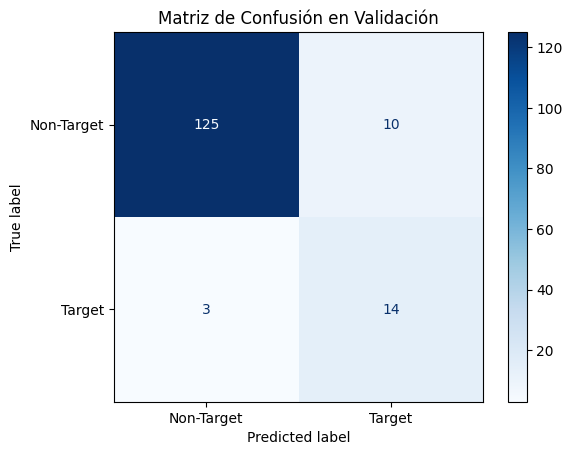

In [16]:
cm = confusion_matrix(y_val_true, y_val_pred, labels=[0, 1])

# Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Target", "Target"])
disp.plot(cmap='Blues', values_format='d')  # 'd' para mostrar enteros
plt.title("Matriz de Confusión en Validación")
plt.show()

# Para toda una sesión

In [28]:
archivos = buscar_edfs_en_sesion("./StudyF", "F_03", "SE001")
X_list, y_list = [], []

for edf_file in archivos:
    X_tmp, y_tmp = cargar_epochs_desde_edf(edf_file)
    X_list.append(X_tmp)
    y_list.append(y_tmp)
X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print(X.shape, y.shape)  # Confirmamos tamaño total
y_cat = to_categorical(y)
y_bin = y_cat.argmax(axis=1)

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_cat,
    test_size=0.2,
    stratify=y_bin,
    random_state=42
)

class_weight = {0: 1.0, 1: 8.0}
callbacks = [
    EarlyStopping(
        monitor='val_recall', mode='max',
        patience=40,
        restore_best_weights=True
    )
]

history = model.fit(
    X_tr, y_tr,
    epochs=300,
    batch_size=16,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)
y_val_true = y_val.argmax(axis=1)
y_val_pred = model.predict(X_val, batch_size=16).argmax(axis=1)

(2268, 8, 205) (2268,)
Epoch 1/300
114/114 [==============================] - 2s 15ms/step - loss: 0.6822 - accuracy: 0.8490 - auc: 0.9221 - recall: 0.8490 - precision: 0.8490 - val_loss: 0.2776 - val_accuracy: 0.9119 - val_auc: 0.9676 - val_recall: 0.9119 - val_precision: 0.9119
Epoch 2/300
114/114 [==============================] - 2s 14ms/step - loss: 0.6421 - accuracy: 0.8423 - auc: 0.9177 - recall: 0.8423 - precision: 0.8423 - val_loss: 0.2775 - val_accuracy: 0.9053 - val_auc: 0.9670 - val_recall: 0.9053 - val_precision: 0.9053
Epoch 3/300
114/114 [==============================] - 2s 13ms/step - loss: 0.6525 - accuracy: 0.8412 - auc: 0.9254 - recall: 0.8412 - precision: 0.8412 - val_loss: 0.2913 - val_accuracy: 0.8965 - val_auc: 0.9604 - val_recall: 0.8965 - val_precision: 0.8965
Epoch 4/300
114/114 [==============================] - 2s 13ms/step - loss: 0.6159 - accuracy: 0.8578 - auc: 0.9286 - recall: 0.8578 - precision: 0.8578 - val_loss: 0.2572 - val_accuracy: 0.9207 - val_au

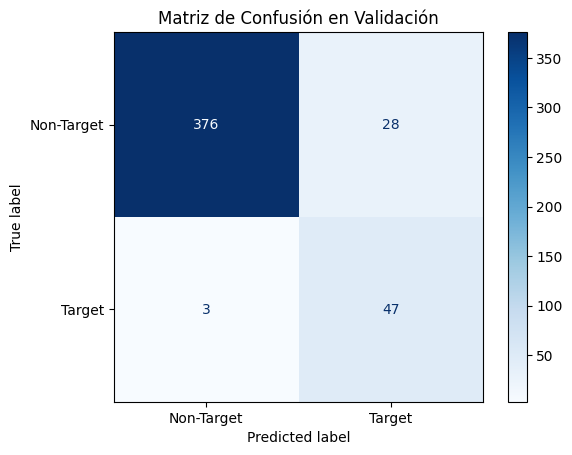

In [29]:
cm = confusion_matrix(y_val_true, y_val_pred, labels=[0, 1])

# Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Target", "Target"])
disp.plot(cmap='Blues', values_format='d')  # 'd' para mostrar enteros
plt.title("Matriz de Confusión en Validación")
plt.show()

# Para 3 sesiones

In [30]:
sesiones = ["SE001", "SE002", "SE003"]
sujeto = "F_03"
base_path = "./StudyF"

X_list, y_list = [], []

for sesion in sesiones:
    archivos = buscar_edfs_en_sesion(base_path, sujeto, sesion, carpeta="Train")
    print(f"Sesión {sesion}: {len(archivos)} archivos encontrados")
    for edf_file in archivos:
        X_tmp, y_tmp = cargar_epochs_desde_edf(edf_file)
        X_list.append(X_tmp)
        y_list.append(y_tmp)

# Concatenar todos los datos
X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
print("Total de epochs:", X.shape, y.shape)

# Preprocesamiento
y_cat = to_categorical(y)
y_bin = y_cat.argmax(axis=1)

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_cat,
    test_size=0.2,
    stratify=y_bin,
    random_state=42
)

# Pesos de clase (ajustable)
class_weight = {0: 1.0, 1: 8.0}
callbacks = [
    EarlyStopping(monitor='val_recall', mode='max', patience=40, restore_best_weights=True)
]

# Entrenamiento del modelo
history = model.fit(
    X_tr, y_tr,
    epochs=300,
    batch_size=16,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# Evaluación
y_val_true = y_val.argmax(axis=1)
y_val_pred = model.predict(X_val, batch_size=16).argmax(axis=1)

Sesión SE001: 3 archivos encontrados
Sesión SE002: 3 archivos encontrados
Sesión SE003: 3 archivos encontrados
Total de epochs: (6804, 8, 205) (6804,)
Epoch 1/300
341/341 [==============================] - 7s 19ms/step - loss: 0.9173 - accuracy: 0.7869 - auc: 0.8481 - recall: 0.7869 - precision: 0.7869 - val_loss: 0.3794 - val_accuracy: 0.8560 - val_auc: 0.9272 - val_recall: 0.8560 - val_precision: 0.8560
Epoch 2/300
341/341 [==============================] - 5s 15ms/step - loss: 0.8519 - accuracy: 0.8014 - auc: 0.8681 - recall: 0.8014 - precision: 0.8014 - val_loss: 0.4388 - val_accuracy: 0.8185 - val_auc: 0.8915 - val_recall: 0.8185 - val_precision: 0.8185
Epoch 3/300
341/341 [==============================] - 5s 16ms/step - loss: 0.8229 - accuracy: 0.7975 - auc: 0.8656 - recall: 0.7975 - precision: 0.7975 - val_loss: 0.3106 - val_accuracy: 0.8957 - val_auc: 0.9578 - val_recall: 0.8957 - val_precision: 0.8957
Epoch 4/300
341/341 [==============================] - 5s 15ms/step - loss:

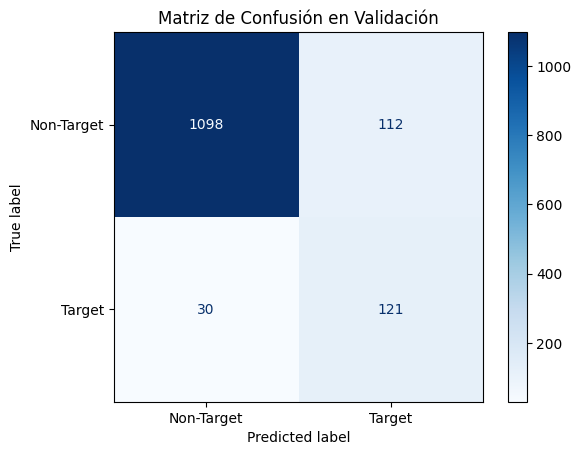

In [31]:
cm = confusion_matrix(y_val_true, y_val_pred, labels=[0, 1])

# Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Target", "Target"])
disp.plot(cmap='Blues', values_format='d')  # 'd' para mostrar enteros
plt.title("Matriz de Confusión en Validación")
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

acc     = accuracy_score(y_val_true, y_val_pred)
prec    = precision_score(y_val_true, y_val_pred, zero_division=0)
rec     = recall_score(y_val_true, y_val_pred, zero_division=0)
f1      = f1_score(y_val_true, y_val_pred, zero_division=0)

# Impresión
print("=== Métricas en Validación ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\n=== Reporte por clase ===")
print(classification_report(y_val_true, y_val_pred, target_names=["non-target", "target"]))


=== Métricas en Validación ===
Accuracy : 0.8957
Precision: 0.5193
Recall   : 0.8013
F1 Score : 0.6302

=== Reporte por clase ===
              precision    recall  f1-score   support

  non-target       0.97      0.91      0.94      1210
      target       0.52      0.80      0.63       151

    accuracy                           0.90      1361
   macro avg       0.75      0.85      0.78      1361
weighted avg       0.92      0.90      0.90      1361



In [36]:
base_path = "./StudyF"
sujetos = ["F_03", "F_05", "F_06", "F_07","F_08","F_20","F_21","F_23","F_24","F_25"]  # Lista de sujetos que tienes

X_list, y_list = [], []

for sujeto in sujetos:
    sujeto_path = os.path.join(base_path, sujeto)
    if not os.path.isdir(sujeto_path):
        print(f"[!] Ruta no encontrada: {sujeto_path}")
        continue

    sesiones_disponibles = [
        sesion for sesion in os.listdir(sujeto_path)
        if os.path.isdir(os.path.join(sujeto_path, sesion)) and sesion.startswith("SE")
    ]

    for sesion in sesiones_disponibles:
        archivos = buscar_edfs_en_sesion(base_path, sujeto, sesion, carpeta="Train")
        print(f"[{sujeto} - {sesion}] EDFs encontrados: {len(archivos)}")
        for edf_file in archivos:
            try:
                X_tmp, y_tmp = cargar_epochs_desde_edf(edf_file)
                X_list.append(X_tmp)
                y_list.append(y_tmp)
            except Exception as e:
                print(f"⚠️ Error al cargar {edf_file}: {e}")

# Concatenar todo
X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
print(f"✅ Total de datos: {X.shape}, Etiquetas: {y.shape}")

# Preprocesamiento
y_cat = to_categorical(y)
y_bin = y_cat.argmax(axis=1)

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_cat,
    test_size=0.2,
    stratify=y_bin,
    random_state=42
)

# Entrenamiento
class_weight = {0: 1.0, 1: 8.0}
callbacks = [
    EarlyStopping(monitor='val_recall', mode='max', patience=40, restore_best_weights=True)
]

history = model.fit(
    X_tr, y_tr,
    epochs=300,
    batch_size=16,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

[F_03 - SE001] EDFs encontrados: 3
[F_03 - SE002] EDFs encontrados: 3
[F_03 - SE003] EDFs encontrados: 3
[F_05 - SE001] EDFs encontrados: 3
[F_05 - SE002] EDFs encontrados: 3
[F_05 - SE003] EDFs encontrados: 3
[F_06 - SE001] EDFs encontrados: 3
[F_06 - SE002] EDFs encontrados: 3
[F_06 - SE003] EDFs encontrados: 3
[F_07 - SE001] EDFs encontrados: 3
[F_07 - SE002] EDFs encontrados: 3
[F_07 - SE003] EDFs encontrados: 3
[F_08 - SE001] EDFs encontrados: 3
[F_08 - SE002] EDFs encontrados: 3
[F_08 - SE003] EDFs encontrados: 3
[F_20 - SE001] EDFs encontrados: 3
[F_20 - SE002] EDFs encontrados: 3
[F_20 - SE003] EDFs encontrados: 3
[F_21 - SE001] EDFs encontrados: 3
[F_21 - SE002] EDFs encontrados: 3
[F_21 - SE003] EDFs encontrados: 3
[F_23 - SE001] EDFs encontrados: 3
[F_23 - SE002] EDFs encontrados: 3
[F_23 - SE003] EDFs encontrados: 3
[F_24 - SE001] EDFs encontrados: 3
[F_24 - SE002] EDFs encontrados: 3
[F_24 - SE003] EDFs encontrados: 3
[F_25 - SE001] EDFs encontrados: 3
[F_25 - SE002] EDFs 

851/851 [==============================] - 2s 2ms/step


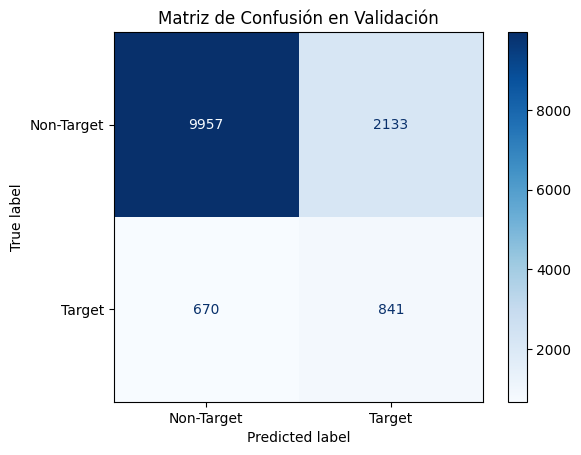

In [40]:
y_val_true = y_val.argmax(axis=1)
y_val_pred = model.predict(X_val, batch_size=16).argmax(axis=1)
cm = confusion_matrix(y_val_true, y_val_pred, labels=[0, 1])

# Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Target", "Target"])
disp.plot(cmap='Blues', values_format='d')  # 'd' para mostrar enteros
plt.title("Matriz de Confusión en Validación")
plt.show()

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

acc     = accuracy_score(y_val_true, y_val_pred)
prec    = precision_score(y_val_true, y_val_pred, zero_division=0)
rec     = recall_score(y_val_true, y_val_pred, zero_division=0)
f1      = f1_score(y_val_true, y_val_pred, zero_division=0)

# Impresión
print("=== Métricas en Validación ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\n=== Reporte por clase ===")
print(classification_report(y_val_true, y_val_pred, target_names=["non-target", "target"]))

=== Métricas en Validación ===
Accuracy : 0.8957
Precision: 0.5193
Recall   : 0.8013
F1 Score : 0.6302

=== Reporte por clase ===
              precision    recall  f1-score   support

  non-target       0.97      0.91      0.94      1210
      target       0.52      0.80      0.63       151

    accuracy                           0.90      1361
   macro avg       0.75      0.85      0.78      1361
weighted avg       0.92      0.90      0.90      1361

